# DANDI 000978 NWB → NeuroPy pipeline

Loads locally downloaded [DANDI 000978 — Single Day W-Track Learning](https://dandiarchive.org/dandiset/000978) NWB files from `download/000978` via registered `NWBDataSessionFormat` / `DataSessionLoader.dandi_nwb_session`, then runs downstream pipeline cells (flattened spikes, position QC, epoch slicing).

Analogous to [`pho_NeuroPy_pipeline_RatJ_Day3TwoNovel.ipynb`](../tools/bapun_sess_init_scripts/notebooks/pho_NeuroPy_pipeline_RatJ_Day3TwoNovel.ipynb), but skips raw `.dat` concatenation, Klusta/Kilosort, and Phy export — spikes and position are read from NWB (or from export cache on reload).

**Paths:** `sess.basepath` is the NWB subject folder under `download/000978/`; `sess.filePrefix` is the export cache stem under `export/000978/{SUBJECT}/`.

**Install:** `uv sync --all-extras --python 3.10`

**References:** [PyNWB read basics](https://pynwb.readthedocs.io/en/stable/tutorials/general/plot_read_basics.html), [NWB overview](https://nwb-overview.readthedocs.io/en/latest/intro_to_nwb/1_intro_to_nwb.html)

**Note:** ER1 NWB is ~28 GB. First load reads NWB; later loads use cached `.npy` files. Plots subsample points. LFP is out of scope for v1.


In [1]:
%config IPCompleter.use_jedi = False
%pdb off
%load_ext autoreload
%autoreload 3

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from pynwb import NWBHDF5IO
from neuropy.core.session.data_session_loader import DataSessionLoader
from neuropy.core.session.Formats.Specific.NWBDataSessionFormat import NWBDataSessionFormatRegisteredClass


Automatic pdb calling has been turned OFF


H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\NeuroPy\neuropy\utils\mixins\time_slicing.py:405: UserWarning: registration of accessor <class 'neuropy.utils.mixins.time_slicing.TimePointEventAccessor'> under name 'time_point_event' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  class TimePointEventAccessor(TimeColumnAliasesProtocol, TimeSlicableObjectProtocol, DataframeMetadataProtocol):


In [2]:
# REPO_ROOT = Path('/media/halechr/BETAMAX1/Data/CRCNS').resolve() # Path('..').resolve() if (Path('..') / 'download').exists() else Path('.').resolve()
# DATA_ROOT = REPO_ROOT / 'download' / '000978'
# EXPORT_ROOT = REPO_ROOT / 'export' / '000978'

# Apogee _____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
REPO_ROOT = Path(r"H:\Data\DANDI\SingleDayWTrackLearning").resolve()
DATA_ROOT = REPO_ROOT / '000978'
EXPORT_ROOT = REPO_ROOT / 'export'

SUBJECT = 'ER1'
SESSION_BASEDIR = DATA_ROOT / f'sub-JDS-SingleDay-{SUBJECT}'
NWB_FILENAME = None  # set for ZT2 multi-file subjects
UNIT_LOCATION_FILTER = 'CA1'
PLOT_SUBSAMPLE = 10

assert DATA_ROOT.is_dir(), f'Missing data root: {DATA_ROOT}'
assert SESSION_BASEDIR.is_dir(), f'Missing subject dir: {SESSION_BASEDIR}'
print('REPO_ROOT:', REPO_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('SESSION_BASEDIR:', SESSION_BASEDIR)
print('SUBJECT:', SUBJECT, '| unit filter:', UNIT_LOCATION_FILTER)


REPO_ROOT: H:\Data\DANDI\SingleDayWTrackLearning
DATA_ROOT: H:\Data\DANDI\SingleDayWTrackLearning\000978
SESSION_BASEDIR: H:\Data\DANDI\SingleDayWTrackLearning\000978\sub-JDS-SingleDay-ER1
SUBJECT: ER1 | unit filter: CA1


In [3]:
nwb_files = sorted(DATA_ROOT.rglob('*.nwb'))
print(f'Found {len(nwb_files)} NWB files under {DATA_ROOT}')
for p in nwb_files:
    print(' -', p.relative_to(DATA_ROOT))

nwb_path = NWBDataSessionFormatRegisteredClass.find_nwb_file(SESSION_BASEDIR, nwb_filename=NWB_FILENAME)
print('Selected NWB:', nwb_path)


Found 9 NWB files under H:\Data\DANDI\SingleDayWTrackLearning\000978
 - sub-JDS-SingleDay-ER1\sub-JDS-SingleDay-ER1_behavior+ecephys.nwb
 - sub-JDS-SingleDay-JS14\sub-JDS-SingleDay-JS14_behavior+ecephys.nwb
 - sub-JDS-SingleDay-JS15\sub-JDS-SingleDay-JS15_behavior+ecephys.nwb
 - sub-JDS-SingleDay-JS17\sub-JDS-SingleDay-JS17_behavior+ecephys.nwb
 - sub-JDS-SingleDay-JS21\sub-JDS-SingleDay-JS21_behavior+ecephys.nwb
 - sub-JDS-SingleDay-JS34\sub-JDS-SingleDay-JS34_behavior+ecephys.nwb
 - sub-JDS-SingleDay-KL8\sub-JDS-SingleDay-KL8_behavior+ecephys.nwb
 - sub-JDS-SingleDay-ZT2\sub-JDS-SingleDay-ZT2_obj-1dss6zi_behavior+ecephys.nwb
 - sub-JDS-SingleDay-ZT2\sub-JDS-SingleDay-ZT2_obj-u40err_behavior+ecephys.nwb
Selected NWB: H:\Data\DANDI\SingleDayWTrackLearning\000978\sub-JDS-SingleDay-ER1\sub-JDS-SingleDay-ER1_behavior+ecephys.nwb


In [4]:
def _unit_electrode_field(electrodes_row, field: str) -> str:
    if hasattr(electrodes_row, '__getitem__') and field in getattr(electrodes_row, 'columns', []):
        return str(electrodes_row[field].values[0])
    return ''

with NWBHDF5IO(str(nwb_path), mode='r') as io:
    nwbf = io.read()
    print('session_id:', nwbf.session_id)
    print('intervals:', list(nwbf.intervals.keys()) if nwbf.intervals else None)
    if nwbf.intervals:
        for key in nwbf.intervals.keys():
            ti = nwbf.intervals[key]
            print(f'  {key}: {len(ti)} rows, cols={list(ti.colnames)}')
    ss = nwbf.processing['behavior']['Position'].spatial_series['SpatialSeries']
    print('SpatialSeries shape:', ss.data.shape, '| unit:', ss.unit)
    udf = nwbf.units.to_dataframe()
    print('units:', len(udf), '| columns:', list(udf.columns))
    loc_counts = udf['electrodes'].apply(lambda e: _unit_electrode_field(e, 'location')).value_counts()
    print('unit locations:\n', loc_counts)
    display(udf.head(3))


session_id: 01
intervals: ['epoch intervals', 'trials']
  epoch intervals: 17 rows, cols=['start_time', 'stop_time']
  trials: 362 rows, cols=['start_time', 'stop_time', 'correct', 'trajectory_type', 'start_well', 'end_well']
SpatialSeries shape: (574019, 3) | unit: centimeters; centimeters/second
units: 122 | columns: ['spike_times', 'electrodes']
unit locations:
 CA1    82
PFC    40
Name: electrodes, dtype: int64


,spike_times,electrodes
id,,
0,"[369.9411, 373.7595, 373.9147, 374.07283333333...",location ...
1,"[365.34846666666664, 365.48453333333333, 365.6...",location ...
2,"[372.6111666666667, 379.0138333333333, 384.517...",location ...


In [5]:
override_params = {
    'unit_location_filter': UNIT_LOCATION_FILTER,
    'export_root': str(EXPORT_ROOT),
}
if NWB_FILENAME is not None:
    override_params['nwb_filename'] = NWB_FILENAME

sess = DataSessionLoader.dandi_nwb_session(SESSION_BASEDIR, override_parameters_flat_keypaths_dict=override_params)
print('neurons:', sess.neurons.n_neurons, '| position samples:', len(sess.position.time))
print('paradigm epochs:', len(sess.paradigm.to_dataframe()), '| spikes_df:', sess.spikes_df.shape)
sess


converting neuron_type strings to core.neurons.NeuronType objects...
	 done.
ER1_SingleDay.neurons.npy saved
ER1_SingleDay.position.npy saved
ER1_SingleDay.paradigm.npy saved
Computing flattened_spike_identities results : "build_spike_dataframe(...)"... done.
Computing flattened_spike_types results : "build_spike_dataframe(...)"... done.
Computing flattened_spike_shank_identities results : "build_spike_dataframe(...)"... done.
Computing flattened_spike_linear_unit_spike_idx results : "build_spike_dataframe(...)"... done.
Computing flattened_spike_times results : "build_spike_dataframe(...)"... done.
Sorting flattened_sort_indicies results : "build_spike_dataframe(...)"... done.
Building final dataframe (containing 1558132 spikes) spikes_df results : "build_spike_dataframe(...)"... done.
spikes_df.columns: Index(['flat_spike_idx', 't_seconds', 'aclu', 'unit_id', 'shank',
       'intra_unit_spike_idx', 'neuron_type'],
      dtype='object')
	 Done!
ER1_SingleDay.flattened.spikes.npy saved

H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\NeuroPy\neuropy\core\session\Formats\Specific\NWBDataSessionFormat.py:259: UserWarning: Could not compute NWB linear position for epoch 'run': ('Lengths must match to compare', (574019,), (2,))
  warnings.warn(f"Could not compute NWB linear position for epoch {epoch_label!r}: {e}")


ER1_SingleDay.interpolated_spike_positions.npy saved
done.
neurons: 82 | position samples: 574019
paradigm epochs: 17 | spikes_df: (1558132, 13)


DataSession(sub-JDS-SingleDay-ER1_behavior+ecephys.nwb)

In [6]:
# sess.config.format_name -> dandi_nwb; basepath -> NWB subject folder; filePrefix -> export cache
sess.config


<SessionConfig: {'basepath': WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/000978/sub-JDS-SingleDay-ER1'), 'session_spec': <SessionFolderSpec: {'required_files': [], 'optional_files': [], 'additional_validation_requirements': []};>, 'session_name': 'ER1_SingleDay', 'session_context': IdentifyingContext<('dandi_nwb', 'ER1', '000978', 'SingleDay')>, 'format_name': 'dandi_nwb', 'preprocessing_parameters': ParametersContainer(epoch_estimation_parameters: neuropy.utils.dynamic_container.DynamicContainer
), 'absolute_start_timestamp': 365.3385, 'position_sampling_rate_Hz': 26.845702619731505, 'microseconds_to_seconds_conversion_factor': 1e-06, 'pix2cm': 287.7697841726619, 'x_midpoint': 143.884892086331, 'loaded_track_limits': {}, 'grid_bin_bounds': None, 'real_unit_grid_bin_bounds': None, 'real_cm_grid_bin_bounds': None, 'grid_bin_bin': None, 'track_start_t': None, 'track_end_t': None, 'x_unit_midpoint': 0.5, 'is_resolved': True, 'resolved_required_filespecs_dict': {}, 'resolved_optiona

In [7]:
pos_df = sess.position.to_dataframe().position.compute_speed_info()
print('position duration (s):', pos_df['t'].max() - pos_df['t'].min())
pos_df.head()

position duration (s): 21382.1187


,t,x,y,speed,dt,velocity_x,acceleration_x,velocity_y,acceleration_y,x_smooth,y_smooth,velocity_x_smooth,acceleration_x_smooth,velocity_y_smooth,acceleration_y_smooth,speed_xy
0,0.000000,65.475196,21.013389,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.029600,65.475196,21.013389,0.00000,0.029600,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.066633,65.475196,21.013389,0.00000,0.037033,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.096233,65.565382,20.923203,3.42397,0.029600,3.046832,102.933505,-3.046832,-102.933505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.133233,65.565382,20.923203,0.00000,0.037000,0.000000,-82.346804,0.000000,82.346804,NaN,NaN,NaN,NaN,NaN,NaN,NaN


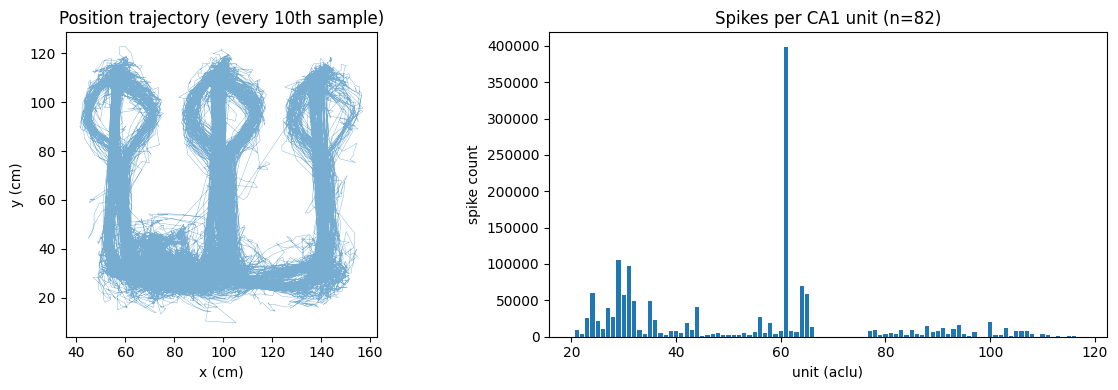

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sub = slice(None, None, PLOT_SUBSAMPLE)
axes[0].plot(sess.position.x[sub], sess.position.y[sub], linewidth=0.3, alpha=0.6)
axes[0].set_xlabel('x (cm)')
axes[0].set_ylabel('y (cm)')
axes[0].set_title(f'Position trajectory (every {PLOT_SUBSAMPLE}th sample)')
axes[0].set_aspect('equal', adjustable='box')
spk_counts = sess.spikes_df.groupby('aclu').size()
axes[1].bar(spk_counts.index, spk_counts.values, width=0.8)
axes[1].set_xlabel('unit (aclu)')
axes[1].set_ylabel('spike count')
axes[1].set_title(f'Spikes per CA1 unit (n={sess.neurons.n_neurons})')
plt.tight_layout()
plt.show()
assert sess.neurons.n_neurons == 82, f'Expected 82 CA1 units for ER1, got {sess.neurons.n_neurons}'

           start          stop  label     duration
0       0.000000    902.840167    run   902.840167
1    1263.229767   2211.040600  sleep   947.810833
2    2284.462100   3234.656167    run   950.194067
3    3424.634300   4395.041467  sleep   970.407167
4    4474.213833   5376.017800    run   901.803967
5    5535.613333   6483.809033  sleep   948.195700
6    6556.749433   7782.333333    run  1225.583900
7    7974.265433   8943.207133  sleep   968.941700
8    9013.446033  10798.965067    run  1785.519033
9   10921.716633  11891.361467  sleep   969.644833
10  11963.680167  13225.375300    run  1261.695133
11  13378.694467  14308.705033  sleep   930.010567
12  14394.908700  15900.204800    run  1505.296100
13  16030.705567  16975.134000  sleep   944.428433
14  17045.491333  18293.767800    run  1248.276467
15  18450.987500  19402.003100  sleep   951.015600
16  19485.734700  21382.118700    run  1896.384000


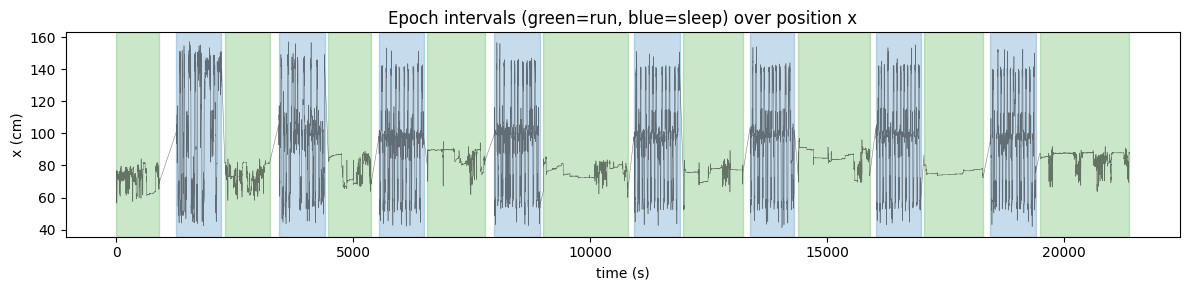

In [9]:
paradigm_df = sess.paradigm.to_dataframe()
print(paradigm_df)
fig, ax = plt.subplots(figsize=(12, 3))
for _, row in paradigm_df.iterrows():
    color = 'tab:green' if row['label'] == 'run' else 'tab:blue'
    ax.axvspan(row['start'], row['stop'], alpha=0.25, color=color)
sub_t = sess.position.time[sub]
ax.plot(sub_t, sess.position.x[sub], linewidth=0.4, color='k', alpha=0.5, label='x (subsampled)')
ax.set_xlabel('time (s)')
ax.set_ylabel('x (cm)')
ax.set_title('Epoch intervals (green=run, blue=sleep) over position x')
plt.tight_layout()
plt.show()

9 run epochs
Run epoch 0: 0.0–902.8 s | pos samples 26855 | spikes 81313


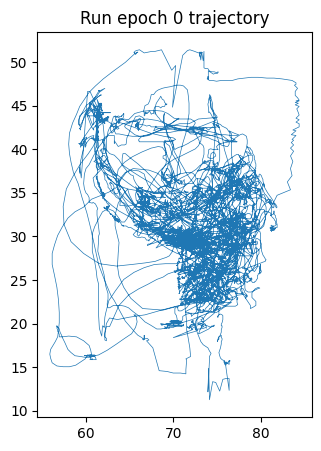

In [10]:
run_epochs_df = paradigm_df[paradigm_df['label'] == 'run'].reset_index(drop=True)
print(f'{len(run_epochs_df)} run epochs')
run_idx = 0
run_start, run_stop = run_epochs_df.loc[run_idx, ['start', 'stop']]
run_pos = sess.position.time_slice(run_start, run_stop)
run_spikes = sess.spikes_df[(sess.spikes_df['t_seconds'] >= run_start) & (sess.spikes_df['t_seconds'] <= run_stop)]
print(f'Run epoch {run_idx}: {run_start:.1f}–{run_stop:.1f} s | pos samples {len(run_pos.time)} | spikes {len(run_spikes)}')
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(run_pos.x, run_pos.y, linewidth=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Run epoch {run_idx} trajectory')
plt.show()

In [11]:
# W-track linearization may need manual track geometry; exploratory only.
try:
    from neuropy.utils import position_util
    linear_pos = position_util.linearize_position(run_pos)
    print('linearized position:', type(linear_pos).__name__)
except Exception as exc:
    print('linearize_position skipped:', exc)

h:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\Spike3D\.venv\lib\site-packages\sklearn\manifold\_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
h:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\Spike3D\.venv\lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
h:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\Spike3D\.venv\lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
h:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\Spike3D\.venv\lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing

linearized position: Position


In [12]:
with NWBHDF5IO(str(sess.recinfo.source_file or nwb_path), mode='r') as io:
    trials_df = io.read().intervals['trials'].to_dataframe()
print('trials:', trials_df.shape)
trials_df.head()


trials: (362, 6)


,start_time,stop_time,correct,trajectory_type,start_well,end_well
id,,,,,,
0,1628.568267,1681.162333,1.0,0.0,1.0,2.0
1,1681.162333,1712.225867,0.0,1.0,2.0,3.0
2,1712.225867,1743.008100,0.0,1.0,3.0,2.0
3,1743.008100,1805.334967,0.0,1.0,2.0,3.0
4,1805.334967,1840.054733,0.0,1.0,3.0,2.0


In [13]:
# Cache is written automatically by NWBDataSessionFormat on first load.
print('Cache at', sess.filePrefix)
print('Files:', sorted(sess.filePrefix.parent.glob(f'{sess.session_name}.*')))


Cache at H:\Data\DANDI\SingleDayWTrackLearning\export\ER1\ER1_SingleDay
Files: [WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay.flattened.spikes.npy'), WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay.interpolated_spike_positions.npy'), WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay.neurons.npy'), WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay.paradigm.npy'), WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay.position.npy')]


In [14]:
# NWB source folder (loader basedir)
sess.basepath


WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/000978/sub-JDS-SingleDay-ER1')

In [15]:
# Export cache stem (standard NeuroPy .npy artifacts)
sess.filePrefix


WindowsPath('H:/Data/DANDI/SingleDayWTrackLearning/export/ER1/ER1_SingleDay')